In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path

In [6]:
d_ap = 10

In [7]:
# ['raw_throughputs',
#  'windowed_throughputs',
#  'time',
#  'mean',
#  'std',
#  'standard_error',
#  'ci_low',
#  'ci_high',
#  'confidence',
#  'critical_value',
#  'n_runs',
#  'total_steps',
#  'window_size',
#  'step_duration']

In [8]:
hmab_static = np.load(f"C:/Users/devarshi/Documents/wifi_9/mapc-cmab/tests/results/HMABS/dynamic/base_line_results/mix_scen_ap_10.0_dsta_2_4_s10000runs_50_steps_10000.npz")
hmab_mean = hmab_static['mean'][:101]
hmab_ci_low = hmab_static['ci_low'][:101]
hmab_ci_high = hmab_static['ci_high'][:101]

In [9]:
hdqn_static = np.load(f"C:/Users/devarshi/Downloads/mapc-cmab/tests/mixed_scenarios/dqn/rotated_scneario/results/updated_dqn_inital_mix_scen_ap_rotated_10.0_dsta_4.0_4.0_s10000_runs_50_steps_10000.npz")
hdqn_mean = hdqn_static['mean'][:101]
hdqn_ci_low = hdqn_static['ci_low'][:101]
hdqn_ci_high = hdqn_static['ci_high'][:101]

In [10]:
step_duration = 0.5
time = np.arange(101) * step_duration

In [11]:

single_ap_throughput = 1208
sl_arr = np.ones(101) * single_ap_throughput


Figure saved to:
presentation_results\Dynamic_throughput_comparison_ap_10.png


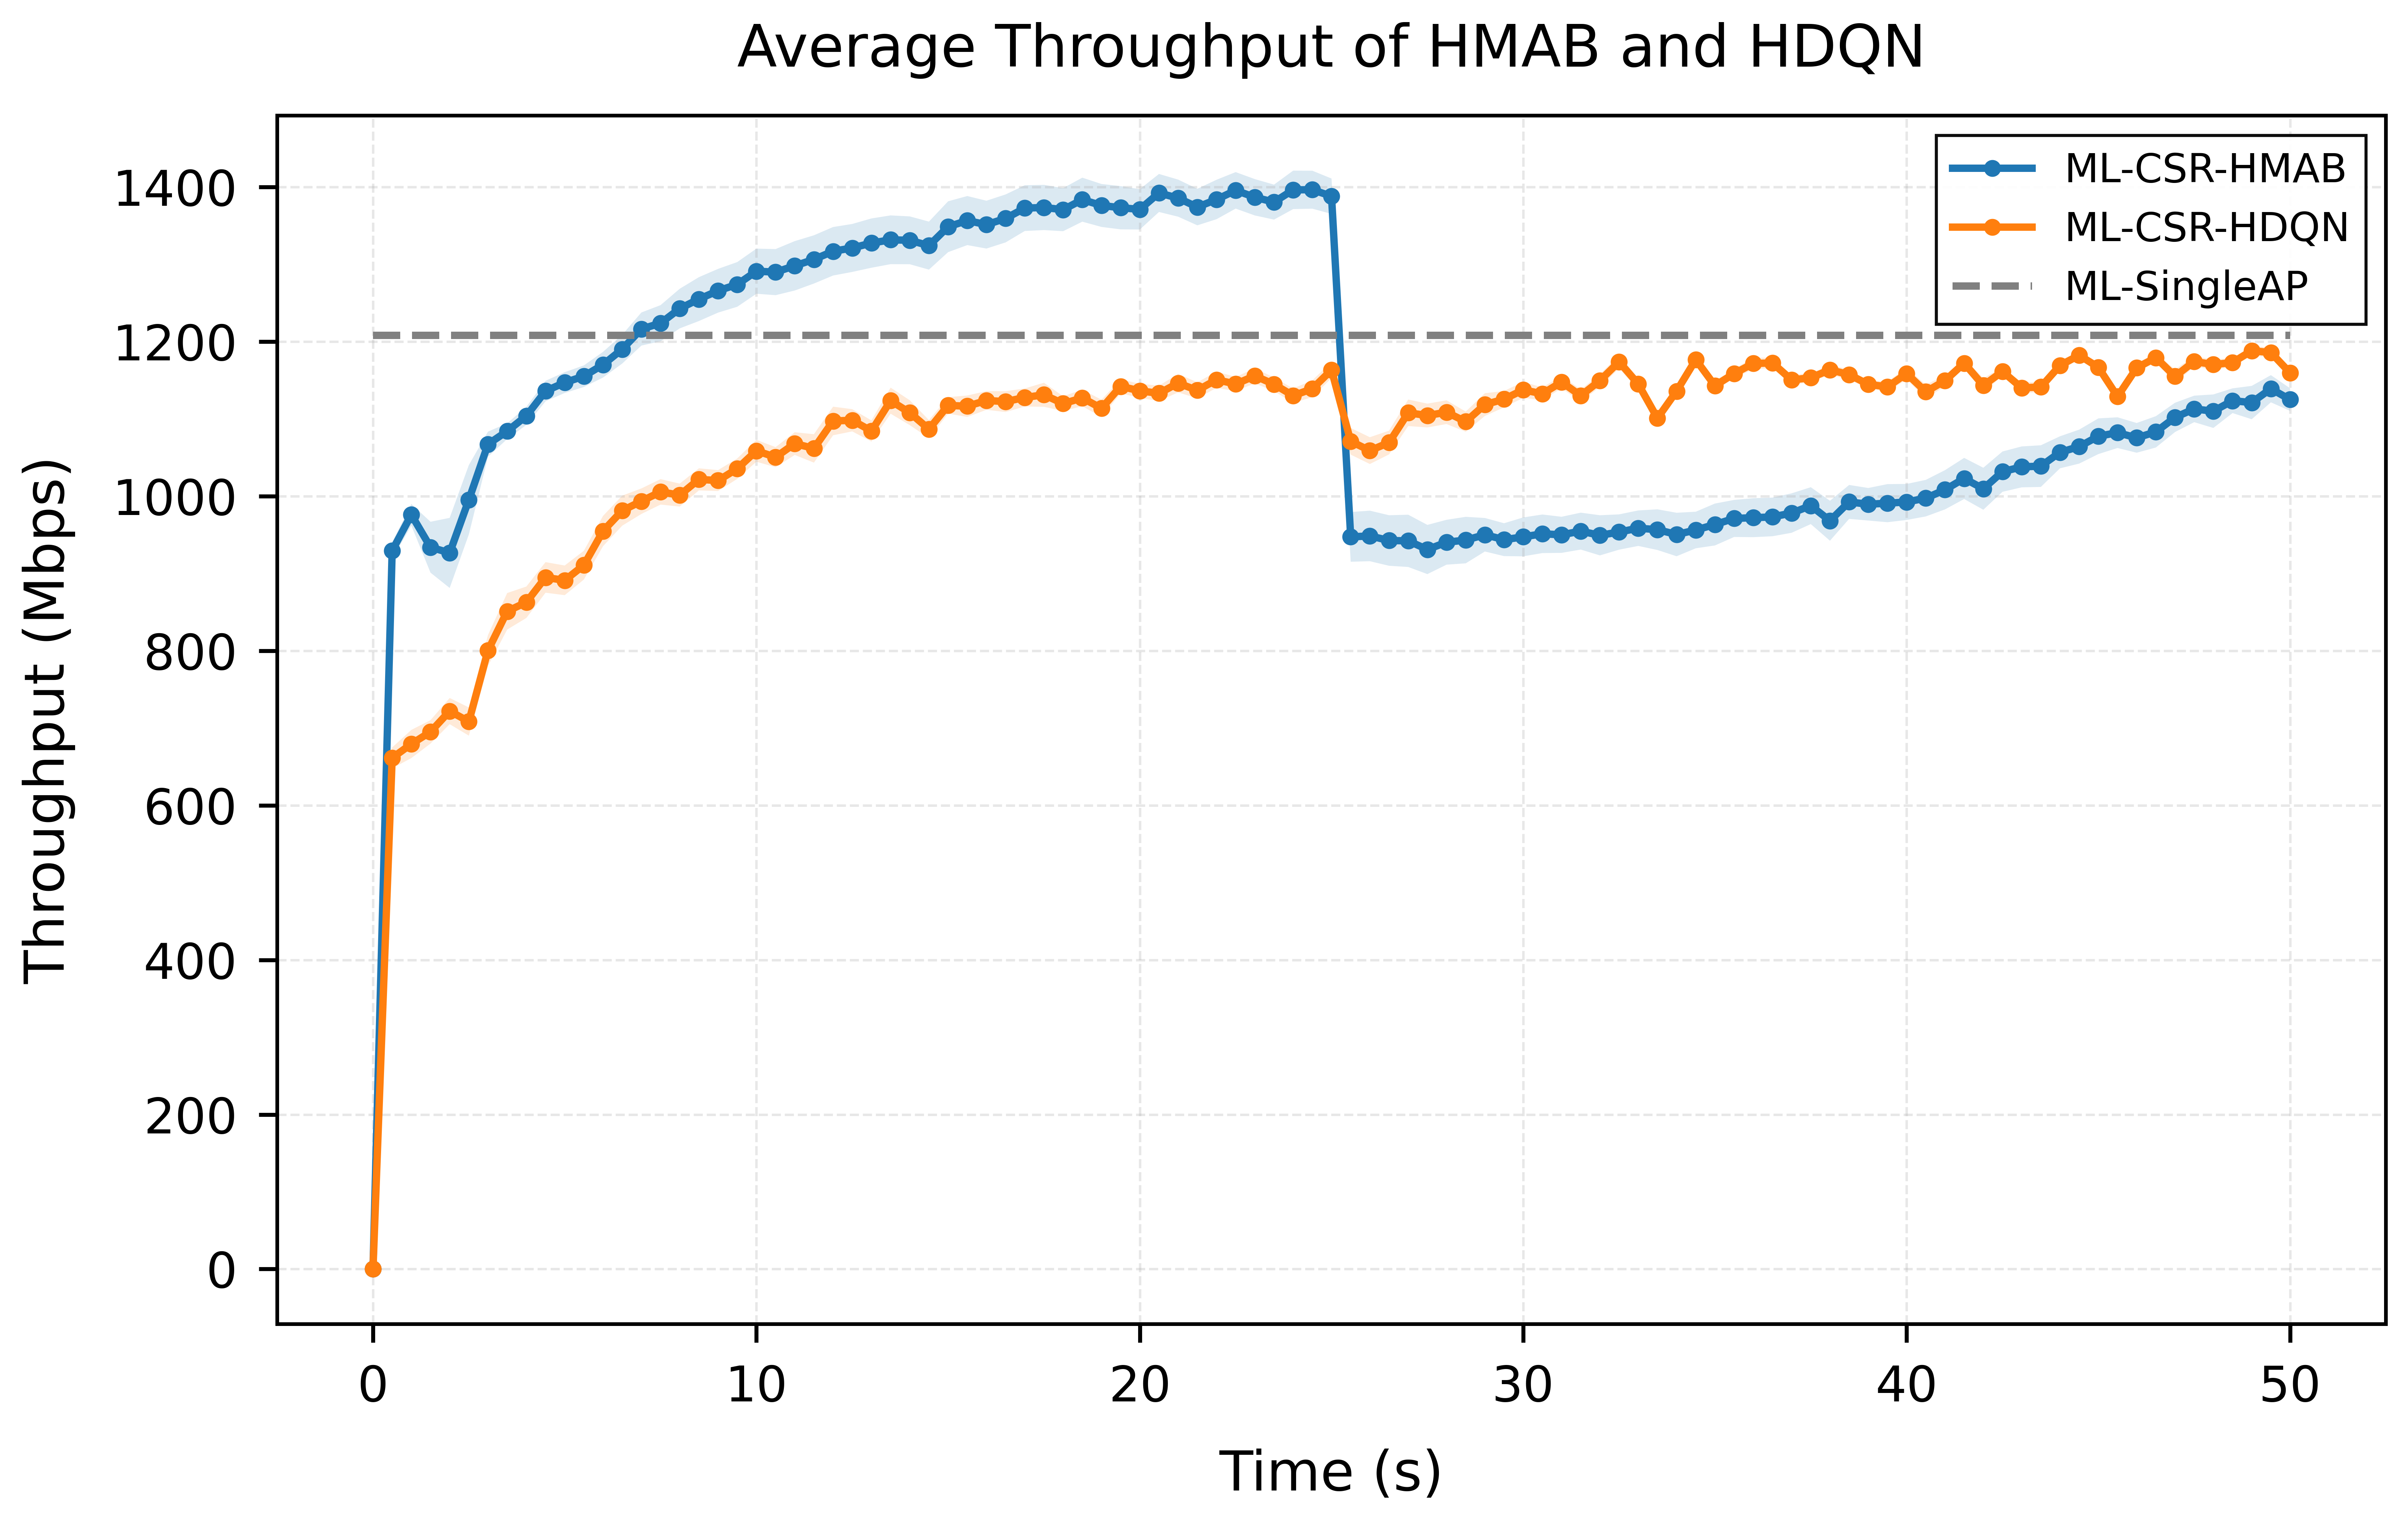

In [12]:

fig, ax = plt.subplots(
    figsize=(11, 7),
    dpi=600,
)




# =========================================================
# ML-CSR-HMAB
# =========================================================

ax.plot(
    time,
    hmab_mean,
    marker="o",
    markersize=4.5,
    linewidth=2.4,
    label="ML-CSR-HMAB",
)

ax.fill_between(
    time,
    hmab_ci_low,
    hmab_ci_high,
    alpha=0.16,
)


# =========================================================
# ML-CSR-HDQN
# =========================================================

ax.plot(
    time,
    hdqn_mean,
    marker="o",
    markersize=4.5,
    linewidth=2.4,
    label="ML-CSR-HDQN",
    # color="lightgreen"
)

ax.fill_between(
    time,
    hdqn_ci_low,
    hdqn_ci_high,
    alpha=0.16,
)

# =========================================================
# ML-SingleAP
# =========================================================

ax.plot(
    time,
    sl_arr,
    linewidth=2.4,
    linestyle="--",
    label="ML-SingleAP",
    color="grey"
)



ax.set_title(
    f"Average Throughput of HMAB and HDQN",
    fontsize=19,
    fontweight="normal",
    pad=16,
)

ax.set_xlabel(
    "Time (s)",
    fontsize=18,
    fontweight="normal",
    labelpad=12,
)

ax.set_ylabel(
    "Throughput (Mbps)",
    fontsize=18,
    fontweight="normal",
    labelpad=12,
)


# =========================================================
# Tick formatting
# =========================================================

ax.tick_params(
    axis="both",
    which="major",
    labelsize=16,
    width=1.3,
    length=6,
    colors="black",
    pad=7,
)


# =========================================================
# Grid
# =========================================================

ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.8,
    alpha=0.30,
)


# =========================================================
# Spines
# =========================================================

for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("black")


# =========================================================
# Legend
# =========================================================

ax.legend(
    fontsize=13,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor="black",
    # loc="best",
)


fig.tight_layout()


# =========================================================
# Save
# =========================================================

output_dir = Path("./presentation_results")
output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    output_dir /
    f"Dynamic_throughput_comparison_ap_{d_ap}.png"
)

fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
)

print(f"Figure saved to:\n{figure_path}")
plt.show()